In [1]:
!git clone https://github.com/deepfindr/gnn-project.git
!pip install rdkit-pypi
!pip install torch_geometric

# Optional dependencies:
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.3.0+cpu.html

# DeepChem for molecular featurization
!pip install deepchem


Cloning into 'gnn-project'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 85 (delta 42), reused 59 (delta 21), pack-reused 0
Receiving objects: 100% (85/85), 3.36 MiB | 10.68 MiB/s, done.
Resolving deltas: 100% (42/42), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 33.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.3.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.7/510.7 kB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.1/777.1 kB 29.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.8/215.8 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   index                                             smiles activity  \
0   3999                  CC1c2nc(N)nc(N)c2CN1C(=O)c1ccccc1       CI   
1   4000              Cc1nc(N)c2c(n1)C(C)N(C(=O)c1ccccc1)C2       CI   
2   4001                              NC(=S)NN=Cc1ccc(O)cn1       CI   
3   4002  COC1C(OC(=O)c2ccc(C)[nH]2)C(O)C(Oc2ccc3c(O)c(N...       CM   
4   4003                      O=C1C=C2C=CC3CC2(O1)C1CCCCN31       CI   

   HIV_active  
0           0  
1           0  
2           0  
3           1  
4           0  
(37128, 4)
HIV_active
0    35850
1     1278
Name: count, dtype: int64


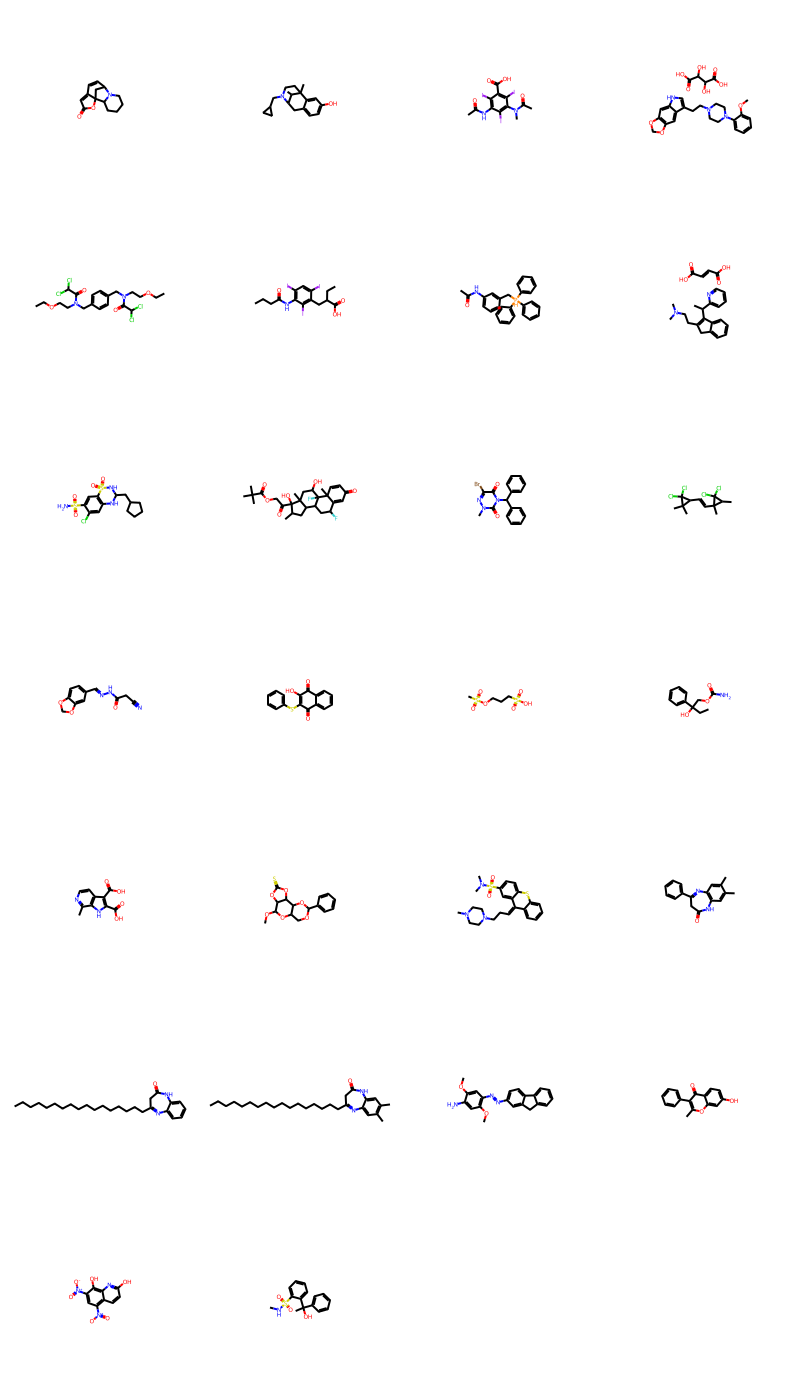

In [2]:
import pandas as pd

DATA_PATH = 'gnn-project/data/raw/HIV_train.csv'
data = pd.read_csv(DATA_PATH)
print(data.head())
print(data.shape)
print(data["HIV_active"].value_counts())

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

sample_smiles = data["smiles"][4:30].values
sample_mol = [Chem.MolFromSmiles(smiles) for smiles in sample_smiles]
grid = Draw.MolsToGridImage(sample_mol, molsPerRow=4, subImgSize=(200, 200))
grid


In [3]:
import torch
import torch_geometric
from torch_geometric.data import Dataset
import numpy as np
import os
from tqdm import tqdm
import deepchem as dc
from rdkit import Chem

print(f"Torch version: {torch.__version__}")
print(f"Cuda available: {torch.cuda.is_available()}")
print(f"Torch geometric version: {torch_geometric.__version__}")

class MoleculeDataset(Dataset):
    def __init__(self, root, filename, test=False, transform=None, pre_transform=None):
        self.test = test
        self.filename = filename
        super(MoleculeDataset, self).__init__(root, transform, pre_transform)

    @property
    def raw_file_names(self):
        return [self.filename]

    @property
    def processed_file_names(self):
        self.data = pd.read_csv(self.raw_paths[0]).reset_index()
        if self.test:
            return [f'data_test_{i}.pt' for i in range(len(self.data))]
        else:
            return [f'data_{i}.pt' for i in range(len(self.data))]

    def download(self):
        pass

    def process(self):
        self.data = pd.read_csv(self.raw_paths[0]).reset_index()
        featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True)
        for index, row in tqdm(self.data.iterrows(), total=self.data.shape[0]):
            mol = Chem.MolFromSmiles(row["smiles"])
            f = featurizer._featurize(mol)
            data = f.to_pyg_graph()
            data.y = self._get_label(row["HIV_active"])
            data.smiles = row["smiles"]
            if self.test:
                torch.save(data, os.path.join(self.processed_dir, f'data_test_{index}.pt'))
            else:
                torch.save(data, os.path.join(self.processed_dir, f'data_{index}.pt'))

    def _get_label(self, label):
        label = np.asarray([label])
        return torch.tensor(label, dtype=torch.int64)

    def len(self):
        return len(self.data)

    def get(self, idx):
        if self.test:
            data = torch.load(os.path.join(self.processed_dir, f'data_test_{idx}.pt'))
        else:
            data = torch.load(os.path.join(self.processed_dir, f'data_{idx}.pt'))
        return data

train_dataset = MoleculeDataset(root="gnn-project/data/", filename="HIV_train.csv")
print(train_dataset[0].edge_index.t())
print(train_dataset[0].x)
print(train_dataset[0].edge_attr)
print(train_dataset[0].y)


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Torch version: 2.3.0+cu121
Cuda available: False
Torch geometric version: 2.5.3


Processing...
 84%|████████▍ | 31138/37128 [06:55<00:57, 104.88it/s][10:09:54] WARNING: not removing hydrogen atom without neighbors
[10:09:54] WARNING: not removing hydrogen atom without neighbors
100%|██████████| 37128/37128 [08:23<00:00, 73.76it/s]

tensor([[ 0,  1],
        [ 1,  0],
        [ 1,  2],
        [ 2,  1],
        [ 2,  3],
        [ 3,  2],
        [ 3,  4],
        [ 4,  3],
        [ 4,  5],
        [ 5,  4],
        [ 4,  6],
        [ 6,  4],
        [ 6,  7],
        [ 7,  6],
        [ 7,  8],
        [ 8,  7],
        [ 7,  9],
        [ 9,  7],
        [ 9, 10],
        [10,  9],
        [10, 11],
        [11, 10],
        [11, 12],
        [12, 11],
        [12, 13],
        [13, 12],
        [12, 14],
        [14, 12],
        [14, 15],
        [15, 14],
        [15, 16],
        [16, 15],
        [16, 17],
        [17, 16],
        [17, 18],
        [18, 17],
        [18, 19],
        [19, 18],
        [11,  1],
        [ 1, 11],
        [19, 14],
        [14, 19],
        [ 9,  2],
        [ 2,  9]])
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,


Done!


In [4]:
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, BatchNorm1d, ModuleList
from torch_geometric.nn import GATConv, TopKPooling, global_mean_pool as gap, global_max_pool as gmp

torch.manual_seed(42)

class GNN(torch.nn.Module):
    def __init__(self, feature_size):
        super(GNN, self).__init__()
        num_classes = 2
        embedding_size = 1024

        self.conv1 = GATConv(feature_size, embedding_size, heads=3, dropout=0.3)
        self.head_transform1 = Linear(embedding_size * 3, embedding_size)
        self.pool1 = TopKPooling(embedding_size, ratio=0.8)
        self.conv2 = GATConv(embedding_size, embedding_size, heads=3, dropout=0.3)
        self.head_transform2 = Linear(embedding_size * 3, embedding_size)
        self.pool2 = TopKPooling(embedding_size, ratio=0.5)
        self.conv3 = GATConv(embedding_size, embedding_size, heads=3, dropout=0.3)
        self.head_transform3 = Linear(embedding_size * 3, embedding_size)
        self.pool3 = TopKPooling(embedding_size, ratio=0.2)

        self.linear1 = Linear(embedding_size * 2, 1024)
        self.linear2 = Linear(1024, num_classes)

    def forward(self, x, edge_attr, edge_index, batch_index):
        x = self.conv1(x, edge_index)
        x = self.head_transform1(x)
        x, edge_index, edge_attr, batch_index, _, _ = self.pool1(x, edge_index, None, batch_index)
        x1 = torch.cat([gmp(x, batch_index), gap(x, batch_index)], dim=1)

        x = self.conv2(x, edge_index)
        x = self.head_transform2(x)
        x, edge_index, edge_attr, batch_index, _, _ = self.pool2(x, edge_index, None, batch_index)
        x2 = torch.cat([gmp(x, batch_index), gap(x, batch_index)], dim=1)

        x = self.conv3(x, edge_index)
        x = self.head_transform3(x)
        x, edge_index, edge_attr, batch_index, _, _ = self.pool3(x, edge_index, None, batch_index)
        x3 = torch.cat([gmp(x, batch_index), gap(x, batch_index)], dim=1)

        x = x1 + x2 + x3
        x = self.linear1(x).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.linear2(x)

        return x


In [5]:
!pip install mlflow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 30.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.0/233.0 kB 26.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 26.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 12.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.9/202.9 kB 23.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

In [6]:
import torch
from torch_geometric.data import DataLoader
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np
from tqdm import tqdm
import mlflow.pytorch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def calculate_metrics(y_pred, y_true, epoch, type):
    print(f"\n Confusion matrix: \n {confusion_matrix(y_pred, y_true)}")
    print(f"F1 Score: {f1_score(y_true, y_pred)}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred)}")
    print(f"Precision: {precision_score(y_true, y_pred)}")
    print(f"Recall: {recall_score(y_true, y_pred)}")
    try:
        roc = roc_auc_score(y_true, y_pred)
        print(f"ROC AUC: {roc}")
        mlflow.log_metric(key=f"ROC-AUC-{type}", value=float(roc), step=epoch)
    except:
        mlflow.log_metric(key=f"ROC-AUC-{type}", value=float(0), step=epoch)
        print(f"ROC AUC: not defined")

def train(epoch):
    all_preds = []
    all_labels = []
    model.train()
    for _, batch in enumerate(tqdm(train_loader)):
        batch.to(device)
        optimizer.zero_grad()
        pred = model(batch.x.float(), batch.edge_attr.float(), batch.edge_index, batch.batch)
        loss = loss_fn(pred, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        all_preds.append(np.argmax(pred.cpu().detach().numpy(), axis=1))
        all_labels.append(batch.y.cpu().detach().numpy())
    all_preds = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    calculate_metrics(all_preds, all_labels, epoch, "train")
    return loss

def test(epoch):
    all_preds = []
    all_labels = []
    model.eval()
    for batch in test_loader:
        batch.to(device)
        pred = model(batch.x.float(), batch.edge_attr.float(), batch.edge_index, batch.batch)
        loss = loss_fn(pred, batch.y.view(-1))
        all_preds.append(np.argmax(pred.cpu().detach().numpy(), axis=1))
        all_labels.append(batch.y.cpu().detach().numpy())
    all_preds = np.concatenate(all_preds).ravel()
    all_labels = np.concatenate(all_labels).ravel()
    calculate_metrics(all_preds, all_labels, epoch, "test")
    return loss


In [7]:
# Loading the dataset
train_dataset = MoleculeDataset(root="gnn-project/data/", filename="HIV_train_oversampled.csv")
test_dataset = MoleculeDataset(root="gnn-project/data/", filename="HIV_test.csv")

# Loading the model
model = GNN(feature_size=train_dataset[0].x.shape[1])
model = model.to(device)
print(f"Number of parameters: {count_parameters(model)}")

# Loss and Optimizer
weights = torch.tensor([1, 10], dtype=torch.float32).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# Prepare training
NUM_GRAPHS_PER_BATCH = 256
train_loader = DataLoader(train_dataset, batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=NUM_GRAPHS_PER_BATCH, shuffle=True)


Processing...
 27%|██▋       | 19584/71634 [06:12<12:58, 66.83it/s][10:18:29] WARNING: not removing hydrogen atom without neighbors
[10:18:29] WARNING: not removing hydrogen atom without neighbors
100%|██████████| 71634/71634 [22:35<00:00, 52.84it/s]
Done!


Number of parameters: 17954818


/usr/local/lib/python3.10/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [ ]:
with mlflow.start_run():
    for epoch in range(500):
        # Training
        model.train()
        loss = train(epoch=epoch)
        loss = loss.detach().cpu().numpy()
        print(f"Epoch {epoch} | Train Loss {loss}")
        mlflow.log_metric(key="Train loss", value=float(loss), step=epoch)

        # Testing
        model.eval()
        if epoch % 5 == 0:
            loss = test(epoch=epoch)
            loss = loss.detach().cpu().numpy()
            print(f"Epoch {epoch} | Test Loss {loss}")
            mlflow.log_metric(key="Test loss", value=float(loss), step=epoch)

        scheduler.step()
print("Done.")


100%|██████████| 280/280 [1:06:23<00:00, 14.23s/it]



 Confusion matrix: 
 [[    0     0]
 [35850 35784]]
F1 Score: 0.6662570518907446
Accuracy: 0.49953932490158304
Precision: 0.49953932490158304
Recall: 1.0
ROC AUC: 0.5
Epoch 0 | Train Loss 0.2967028319835663

 Confusion matrix: 
 [[   0    0]
 [1976 2023]]
F1 Score: 0.6718698106941215
Accuracy: 0.5058764691172793
Precision: 0.5058764691172793
Recall: 1.0
ROC AUC: 0.5
Epoch 0 | Test Loss 0.29717200994491577


100%|██████████| 280/280 [1:06:58<00:00, 14.35s/it]



 Confusion matrix: 
 [[    0     0]
 [35850 35784]]
F1 Score: 0.6662570518907446
Accuracy: 0.49953932490158304
Precision: 0.49953932490158304
Recall: 1.0
ROC AUC: 0.5
Epoch 1 | Train Loss 0.293368935585022


 44%|████▎     | 122/280 [28:54<37:35, 14.28s/it]